# Semi-Supervised Learning for Hardness Prediction

---

## Objective

This notebook implements a **semi-supervised learning** approach to predict **Hardness (kg/mm²)** for welding quality assessment.

### Why Semi-Supervised Learning?

- **Sparse labeled data**: Only ~138 labeled hardness samples (8.4% of dataset)
- **Abundant unlabeled data**: ~1514 unlabeled samples available
- **Goal**: Leverage unlabeled data through self-training to improve model performance beyond pure supervised learning

### Approach

1. **Baseline**: Train supervised models (Random Forest & XGBoost) on labeled data only
2. **Self-Training**: Iteratively add confident pseudo-labels from unlabeled data
3. **Comparison**: Evaluate if semi-supervised approach improves over supervised baseline
4. **Deployment**: Use best model to predict all missing hardness values

## Setup and Imports

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, GridSearchCV, KFold

# Models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Utilities
import joblib
import os

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## Load and Explore Data

Load the welding database with original features (chemical composition, welding parameters, etc.).

In [2]:
# Load dataset
df = pd.read_csv('../../welddatabase/welddb_new.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names (first 10):")
print(df.columns.tolist()[:10])
print(f"\nColumn names (last 10):")
print(df.columns.tolist()[-10:])

# Check hardness availability
hardness_available = df['Hardness_kg_mm2'].notna().sum()
hardness_missing = df['Hardness_kg_mm2'].isna().sum()
hardness_pct = (hardness_available / len(df)) * 100

print(f"\n{'='*60}")
print(f"HARDNESS DATA AVAILABILITY")
print(f"{'='*60}")
print(f"Total samples: {len(df)}")
print(f"Labeled (available): {hardness_available} ({hardness_pct:.2f}%)")
print(f"Unlabeled (missing): {hardness_missing} ({100-hardness_pct:.2f}%)")
print(f"{'='*60}")

Dataset shape: (1652, 52)

Column names (first 10):
['Carbon_%', 'Silicon_%', 'Manganese_%', 'Sulphur_%', 'Phosphorus_%', 'Nickel_%', 'Chromium_%', 'Molybdenum_%', 'Vanadium_%', 'Copper_%']

Column names (last 10):
['Weld_Type_GMAA', 'Weld_Type_GTAA', 'Weld_Type_MMA', 'Weld_Type_NGGMA', 'Weld_Type_NGSAW', 'Weld_Type_SA', 'Weld_Type_SAA', 'Weld_Type_ShMA', 'Weld_Type_TSA', 'Heat_Input_J_mm']

HARDNESS DATA AVAILABILITY
Total samples: 1652
Labeled (available): 138 (8.35%)
Unlabeled (missing): 1514 (91.65%)


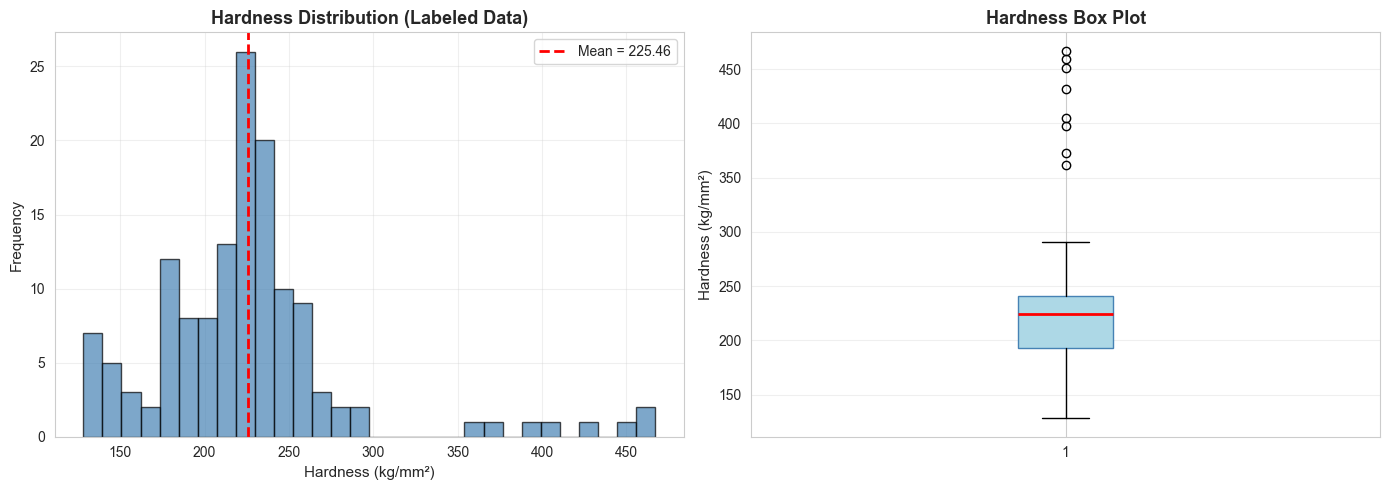


Hardness statistics (labeled data):
count    138.000000
mean     225.463039
std       60.384922
min      128.122060
25%      193.000000
50%      224.000000
75%      241.000000
max      467.000000
Name: Hardness_kg_mm2, dtype: float64


In [3]:
# Visualize hardness distribution for labeled data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
hardness_labeled = df['Hardness_kg_mm2'].dropna()
axes[0].hist(hardness_labeled, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Hardness Distribution (Labeled Data)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hardness (kg/mm²)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].axvline(hardness_labeled.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {hardness_labeled.mean():.2f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(hardness_labeled, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Hardness Box Plot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Hardness (kg/mm²)', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('figures/hardness_initial_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nHardness statistics (labeled data):")
print(hardness_labeled.describe())

## Data Preparation

### Strategy:

1. **Isolate target**: Keep only Hardness as target, exclude other Group 2 properties to prevent leakage
2. **Feature preprocessing**:
   - MinMax scaling (0-1 range)
   - KNN imputation for missing features (k=5 neighbors)
3. **Split labeled/unlabeled**: Separate samples with known hardness vs missing hardness
4. **Two datasets**:
   - **Supervised dataset**: Only labeled samples
   - **Semi-supervised dataset**: Labeled + unlabeled combined

In [4]:
# Define target and other Group 2 properties to exclude
target_column = 'Hardness_kg_mm2'
group2_exclude = ['FATT_50%', 'Primary_Ferrite_%', 'Ferrite_2nd_Phase_%', 
                  'Acicular_Ferrite_%', 'Martensite_%', 'Ferrite_Carbide_%']

# Also exclude Group 1 properties (already predicted in previous phase)
group1_exclude = ['Yield_Strength_MPa', 'UTS_MPa', 'Elongation_%', 
                  'Reduction_Area_%', 'Charpy_Temp_C', 'Charpy_Energy_J']

# Extract features (X) and target (y)
# Use all remaining columns as features (chemical composition, welding parameters, etc.)
X_all = df.drop(columns=[target_column] + group2_exclude + group1_exclude, errors='ignore')
y_all = df[target_column].copy()

print(f"Feature matrix shape: {X_all.shape}")
print(f"Target vector shape: {y_all.shape}")
print(f"\nFeature columns ({len(X_all.columns)} total):")
if len(X_all.columns) <= 30:
    print(X_all.columns.tolist())
else:
    print(X_all.columns.tolist()[:15])
    print(f"... ({len(X_all.columns) - 15} more features)")
print(f"\nFeature categories:")
print(f"  - Chemical composition (Carbon, Silicon, Manganese, etc.)")
print(f"  - Welding parameters (Interpass Temp, PWHT, Heat Input, etc.)")
print(f"  - Process variables (Electrode Polarity, Weld Type, Power, etc.)")

Feature matrix shape: (1652, 39)
Target vector shape: (1652,)

Feature columns (39 total):
['Carbon_%', 'Silicon_%', 'Manganese_%', 'Sulphur_%', 'Phosphorus_%', 'Nickel_%', 'Chromium_%', 'Molybdenum_%', 'Vanadium_%', 'Copper_%', 'Cobalt_%', 'Tungsten_%', 'Oxygen_weight%', 'Titanium_weight%', 'Nitrogen_weight%']
... (24 more features)

Feature categories:
  - Chemical composition (Carbon, Silicon, Manganese, etc.)
  - Welding parameters (Interpass Temp, PWHT, Heat Input, etc.)
  - Process variables (Electrode Polarity, Weld Type, Power, etc.)


In [5]:
# Scale features to [0, 1] range
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_all)

# Impute missing features using KNN (k=5)
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
X_imputed = knn_imputer.fit_transform(X_scaled)

# Convert back to DataFrame for clarity
X_clean = pd.DataFrame(X_imputed, columns=X_all.columns, index=X_all.index)

print(f"✓ Features scaled and imputed")
print(f"Missing values remaining: {X_clean.isna().sum().sum()}")

✓ Features scaled and imputed
Missing values remaining: 0


In [6]:
# Split into labeled and unlabeled sets
labeled_mask = y_all.notna()
unlabeled_mask = y_all.isna()

# Supervised dataset (labeled only)
X_labeled = X_clean[labeled_mask].copy()
y_labeled = y_all[labeled_mask].copy()

# Unlabeled features (for semi-supervised)
X_unlabeled = X_clean[unlabeled_mask].copy()

print(f"\n{'='*60}")
print(f"DATA SPLIT SUMMARY")
print(f"{'='*60}")
print(f"Labeled samples: {len(X_labeled)}")
print(f"Unlabeled samples: {len(X_unlabeled)}")
print(f"Feature dimension: {X_clean.shape[1]}")
print(f"{'='*60}")

# Further split labeled data into train/test for evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X_labeled, y_labeled, test_size=0.2, random_state=42
)

print(f"\nTrain/Test split (from labeled data):")
print(f"  Train: {len(X_train)} samples")
print(f"  Test:  {len(X_test)} samples")


DATA SPLIT SUMMARY
Labeled samples: 138
Unlabeled samples: 1514
Feature dimension: 39

Train/Test split (from labeled data):
  Train: 110 samples
  Test:  28 samples


## Custom Self-Training Regressor

### How Self-Training Works:

1. **Initial fit**: Train base model on labeled data
2. **Predict unlabeled**: Generate predictions for all unlabeled samples
3. **Confidence estimation**: 
   - For ensemble models (RF): Use prediction variance across trees
   - For boosting (XGB): Use staged prediction variance
   - Confidence = 1 / (1 + variance)
4. **Pseudo-labeling**: Select top-k% most confident predictions
5. **Expand training set**: Add pseudo-labeled samples to training data
6. **Retrain**: Fit model on expanded labeled set
7. **Repeat**: Continue until max iterations or convergence

### Key Parameters:
- `confidence_threshold`: Fraction of unlabeled data to pseudo-label per iteration (default: 0.15 = 15%)
- `max_iter`: Maximum number of self-training iterations (default: 10)
- `rmse_threshold`: Minimum confidence criterion based on target's standard deviation

In [7]:
class SelfTrainingRegressor:
    """
    Self-training regressor for semi-supervised learning.
    
    Iteratively expands labeled dataset by adding high-confidence pseudo-labels
    from unlabeled data.
    """
    
    def __init__(self, base_estimator, confidence_threshold=0.15, max_iter=10, rmse_threshold=None):
        """
        Args:
            base_estimator: sklearn-compatible regressor (must support fit/predict)
            confidence_threshold: fraction of unlabeled samples to add per iteration
            max_iter: maximum number of self-training iterations
            rmse_threshold: optional confidence gate based on target std
        """
        self.base_estimator = base_estimator
        self.confidence_threshold = confidence_threshold
        self.max_iter = max_iter
        self.rmse_threshold = rmse_threshold
        self.iteration_metrics_ = []
    
    def get_params(self, deep=True):
        """
        Get parameters for this estimator (required for GridSearchCV compatibility).
        """
        params = {
            'base_estimator': self.base_estimator,
            'confidence_threshold': self.confidence_threshold,
            'max_iter': self.max_iter,
            'rmse_threshold': self.rmse_threshold
        }
        
        if deep and hasattr(self.base_estimator, 'get_params'):
            # Include base estimator's parameters with prefix
            base_params = self.base_estimator.get_params(deep=True)
            for key, value in base_params.items():
                params[f'base_estimator__{key}'] = value
        
        return params
    
    def set_params(self, **params):
        """
        Set parameters for this estimator (required for GridSearchCV compatibility).
        """
        # Separate base estimator parameters from self-training parameters
        base_estimator_params = {}
        self_params = {}
        
        for key, value in params.items():
            if key.startswith('base_estimator__'):
                # Remove prefix and add to base estimator params
                base_key = key.replace('base_estimator__', '')
                base_estimator_params[base_key] = value
            elif key == 'base_estimator':
                self.base_estimator = value
            else:
                self_params[key] = value
        
        # Set base estimator parameters
        if base_estimator_params and hasattr(self.base_estimator, 'set_params'):
            self.base_estimator.set_params(**base_estimator_params)
        
        # Set self-training parameters
        for key, value in self_params.items():
            setattr(self, key, value)
        
        return self
        
    def fit(self, X, y):
        """
        Fit self-training model.
        
        Args:
            X: Feature matrix (labeled + unlabeled combined)
            y: Target vector (NaN for unlabeled samples)
        """
        # Separate labeled and unlabeled
        labeled_mask = ~pd.isna(y)
        X_labeled_init = X[labeled_mask].copy()
        y_labeled_init = y[labeled_mask].copy()
        X_unlabeled_pool = X[~labeled_mask].copy()
        
        # Initialize training set
        X_train_current = X_labeled_init.copy()
        y_train_current = y_labeled_init.copy()
        
        print(f"Starting self-training...")
        print(f"Initial labeled: {len(X_labeled_init)}, Unlabeled pool: {len(X_unlabeled_pool)}")
        
        for iteration in range(self.max_iter):
            # Train on current labeled set
            self.base_estimator.fit(X_train_current, y_train_current)
            
            # Break if no unlabeled samples remain
            if len(X_unlabeled_pool) == 0:
                print(f"Iteration {iteration}: No unlabeled samples remaining.")
                break
            
            # Predict on unlabeled pool with confidence estimation
            if hasattr(self.base_estimator, 'estimators_'):  # Ensemble model
                if hasattr(self.base_estimator, 'staged_predict'):  # GradientBoosting
                    staged_preds = list(self.base_estimator.staged_predict(X_unlabeled_pool))
                    recent_preds = np.array(staged_preds[-min(20, len(staged_preds)):])
                    mean_pred = staged_preds[-1]
                    std_pred = recent_preds.std(axis=0)
                else:  # RandomForest
                    tree_preds = np.array([tree.predict(X_unlabeled_pool) 
                                           for tree in self.base_estimator.estimators_])
                    mean_pred = tree_preds.mean(axis=0)
                    std_pred = tree_preds.std(axis=0)
                
                confidence = 1 / (1 + std_pred)  # Higher confidence = lower variance
            else:
                # Fallback: uniform confidence
                mean_pred = self.base_estimator.predict(X_unlabeled_pool)
                confidence = np.ones(len(mean_pred))
            
            # Select top confident predictions
            n_to_add = max(1, int(len(X_unlabeled_pool) * self.confidence_threshold))
            top_indices = np.argsort(confidence)[-n_to_add:]
            
            # Extract pseudo-labeled samples
            X_pseudo = X_unlabeled_pool.iloc[top_indices].copy()
            y_pseudo = pd.Series(mean_pred[top_indices], index=X_pseudo.index)
            
            # Add to training set
            X_train_current = pd.concat([X_train_current, X_pseudo], axis=0)
            y_train_current = pd.concat([y_train_current, y_pseudo], axis=0)
            
            # Remove from unlabeled pool
            X_unlabeled_pool = X_unlabeled_pool.drop(X_unlabeled_pool.index[top_indices])
            
            # Log metrics
            self.iteration_metrics_.append({
                'iteration': iteration,
                'labeled_count': len(X_train_current),
                'added_samples': len(X_pseudo),
                'unlabeled_remaining': len(X_unlabeled_pool),
                'mean_confidence': confidence[top_indices].mean()
            })
            
            print(f"Iteration {iteration}: Added {len(X_pseudo)} pseudo-labels, "
                  f"Total labeled: {len(X_train_current)}, Remaining unlabeled: {len(X_unlabeled_pool)}")
        
        # Final fit on all labeled (original + pseudo-labeled)
        self.base_estimator.fit(X_train_current, y_train_current)
        print(f"\n✓ Self-training complete. Final training set size: {len(X_train_current)}")
        
        return self
    
    def predict(self, X):
        """Generate predictions using the trained base estimator."""
        return self.base_estimator.predict(X)
    
    def get_iteration_metrics(self):
        """Return DataFrame with metrics logged during self-training."""
        return pd.DataFrame(self.iteration_metrics_)

## Custom Cross-Validation Splitter

Standard K-Fold doesn't handle semi-supervised data properly. We need a custom splitter that:

1. **Only folds labeled data** for train/validation splits
2. **Training folds include unlabeled data** (with NaN targets for self-training)
3. **Validation folds contain only labeled data** (for accurate evaluation)

This ensures:
- Model can learn from unlabeled data during training
- Evaluation metrics are calculated only on genuine labels (no pseudo-labels)

In [8]:
class CustomLabeledUnlabeledKFold:
    """
    Custom K-Fold splitter for semi-supervised learning.
    
    Splits only labeled data for validation, but training folds include
    both labeled and unlabeled samples.
    """
    
    def __init__(self, n_splits=5, shuffle=True, random_state=None):
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state
    
    def split(self, X, y=None, groups=None):
        """
        Generate train/validation indices.
        
        Args:
            X: Feature matrix (labeled + unlabeled)
            y: Target vector (NaN for unlabeled)
            groups: Ignored, for compatibility
            
        Yields:
            train_idx, val_idx pairs
        """
        # Convert y to array if it's a Series
        if isinstance(y, pd.Series):
            y_array = y.values
        else:
            y_array = np.array(y)
        
        # Identify labeled samples (non-NaN)
        if y_array is None:
            raise ValueError("y cannot be None for CustomLabeledUnlabeledKFold")
        
        labeled_mask = ~pd.isna(y_array)
        labeled_indices = np.where(labeled_mask)[0]
        unlabeled_indices = np.where(~labeled_mask)[0]
        
        # Check if we have labeled data
        if len(labeled_indices) == 0:
            raise ValueError("No labeled samples found in the dataset")
        
        # Adjust n_splits if we have fewer labeled samples
        actual_n_splits = min(self.n_splits, len(labeled_indices))
        
        if actual_n_splits < self.n_splits:
            print(f"Warning: Reducing n_splits from {self.n_splits} to {actual_n_splits} due to limited labeled samples")
        
        # K-Fold on labeled data only
        kfold = KFold(n_splits=actual_n_splits, shuffle=self.shuffle, random_state=self.random_state)
        
        for train_labeled_idx, val_labeled_idx in kfold.split(labeled_indices):
            # Map back to original indices in the full dataset
            train_labeled = labeled_indices[train_labeled_idx]
            val_labeled = labeled_indices[val_labeled_idx]
            
            # Training set: labeled (train fold) + all unlabeled
            train_idx = np.concatenate([train_labeled, unlabeled_indices])
            
            # Validation set: labeled (val fold) only
            val_idx = val_labeled
            
            yield train_idx, val_idx
    
    def get_n_splits(self, X=None, y=None, groups=None):
        """Return the number of splits."""
        if y is not None:
            # Convert y to array if it's a Series
            if isinstance(y, pd.Series):
                y_array = y.values
            else:
                y_array = np.array(y)
            
            # Count labeled samples
            labeled_count = np.sum(~pd.isna(y_array))
            return min(self.n_splits, labeled_count)
        return self.n_splits

## Baseline: Supervised Learning

Train standard supervised models **using only labeled data** to establish baseline performance.

### Models:
1. **Random Forest** - Ensemble of decision trees, robust to overfitting
2. **XGBoost** - Gradient boosting, often superior for tabular data

### Evaluation Metrics:
- **R²**: Proportion of variance explained (higher is better, max 1.0)
- **Adjusted R²**: R² penalized for number of features
- **RMSE**: Root mean squared error in kg/mm² (lower is better)
- **MAE**: Mean absolute error in kg/mm² (lower is better)

In [9]:
# Train Random Forest (Supervised)
print("Training Random Forest (Supervised)...")

# Hyperparameter grid
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_supervised = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_rf_supervised = GridSearchCV(
    rf_supervised, param_grid_rf, cv=5, scoring='r2', n_jobs=-1, verbose=1
)

grid_rf_supervised.fit(X_train, y_train)

# Best model
best_rf_supervised = grid_rf_supervised.best_estimator_

# Predictions
y_pred_rf_supervised = best_rf_supervised.predict(X_test)

# Metrics
r2_rf_supervised = r2_score(y_test, y_pred_rf_supervised)
n = len(X_train)
p = X_train.shape[1]
adj_r2_rf_supervised = 1 - (1 - r2_rf_supervised) * (n - 1) / (n - p - 1)
rmse_rf_supervised = np.sqrt(mean_squared_error(y_test, y_pred_rf_supervised))
mae_rf_supervised = mean_absolute_error(y_test, y_pred_rf_supervised)

print(f"\n{'='*60}")
print(f"SUPERVISED RANDOM FOREST RESULTS")
print(f"{'='*60}")
print(f"Best parameters: {grid_rf_supervised.best_params_}")
print(f"R²: {r2_rf_supervised:.4f}")
print(f"Adjusted R²: {adj_r2_rf_supervised:.4f}")
print(f"RMSE: {rmse_rf_supervised:.4f} kg/mm²")
print(f"MAE: {mae_rf_supervised:.4f} kg/mm²")
print(f"{'='*60}")

Training Random Forest (Supervised)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

SUPERVISED RANDOM FOREST RESULTS
Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
R²: 0.8337
Adjusted R²: 0.7410
RMSE: 30.1644 kg/mm²
MAE: 20.6784 kg/mm²


In [10]:
# Train XGBoost (Supervised)
print("\nTraining XGBoost (Supervised)...")

# Hyperparameter grid
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_supervised = XGBRegressor(objective='reg:squarederror', random_state=42)
grid_xgb_supervised = GridSearchCV(
    xgb_supervised, param_grid_xgb, cv=5, scoring='r2', n_jobs=-1, verbose=1
)

grid_xgb_supervised.fit(X_train, y_train)

# Best model
best_xgb_supervised = grid_xgb_supervised.best_estimator_

# Predictions
y_pred_xgb_supervised = best_xgb_supervised.predict(X_test)

# Metrics
r2_xgb_supervised = r2_score(y_test, y_pred_xgb_supervised)
adj_r2_xgb_supervised = 1 - (1 - r2_xgb_supervised) * (n - 1) / (n - p - 1)
rmse_xgb_supervised = np.sqrt(mean_squared_error(y_test, y_pred_xgb_supervised))
mae_xgb_supervised = mean_absolute_error(y_test, y_pred_xgb_supervised)

print(f"\n{'='*60}")
print(f"SUPERVISED XGBOOST RESULTS")
print(f"{'='*60}")
print(f"Best parameters: {grid_xgb_supervised.best_params_}")
print(f"R²: {r2_xgb_supervised:.4f}")
print(f"Adjusted R²: {adj_r2_xgb_supervised:.4f}")
print(f"RMSE: {rmse_xgb_supervised:.4f} kg/mm²")
print(f"MAE: {mae_xgb_supervised:.4f} kg/mm²")
print(f"{'='*60}")


Training XGBoost (Supervised)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

SUPERVISED XGBOOST RESULTS
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
R²: 0.9436
Adjusted R²: 0.9121
RMSE: 17.5682 kg/mm²
MAE: 12.8283 kg/mm²


## Semi-Supervised Learning with Self-Training

Now train models using **both labeled and unlabeled data** through self-training.

### Approach:
1. Combine labeled train + unlabeled data
2. Wrap base estimator in SelfTrainingRegressor
3. Use custom CV splitter for proper evaluation
4. Hyperparameter tuning with GridSearchCV
5. Compare against supervised baseline

In [11]:
# Prepare semi-supervised dataset
# Training: labeled train + all unlabeled
X_train_ssl = pd.concat([X_train, X_unlabeled], axis=0).reset_index(drop=True)
y_train_ssl = pd.concat([
    y_train, 
    pd.Series([np.nan] * len(X_unlabeled), index=X_unlabeled.index)
], axis=0).reset_index(drop=True)

print(f"Semi-supervised training set:")
print(f"  Total samples: {len(X_train_ssl)}")
print(f"  Labeled: {y_train_ssl.notna().sum()}")
print(f"  Unlabeled: {y_train_ssl.isna().sum()}")

# Calculate target std for confidence threshold
std_y = y_labeled.std()
print(f"\nTarget standard deviation: {std_y:.4f}")

Semi-supervised training set:
  Total samples: 1624
  Labeled: 110
  Unlabeled: 1514

Target standard deviation: 60.3849


In [12]:
# Train Random Forest with Self-Training
print("\nTraining Random Forest with Self-Training...\n")

# Base RF estimator
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# Wrap in self-training
rf_ssl = SelfTrainingRegressor(
    base_estimator=rf_base, 
    confidence_threshold=0.15,
    max_iter=10,
    rmse_threshold=std_y
)

# Hyperparameter grid (for base estimator)
param_grid_rf_ssl = {
    'base_estimator__n_estimators': [100, 200],
    'base_estimator__max_depth': [10, 20, None],
    'base_estimator__min_samples_split': [2, 5]
}

# Custom CV splitter
custom_cv = CustomLabeledUnlabeledKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search
grid_rf_ssl = GridSearchCV(
    rf_ssl, param_grid_rf_ssl, cv=custom_cv, scoring='r2', n_jobs=1, verbose=1
)

grid_rf_ssl.fit(X_train_ssl, y_train_ssl)

# Best model
best_rf_ssl = grid_rf_ssl.best_estimator_

# Predictions on test set (labeled only)
y_pred_rf_ssl = best_rf_ssl.predict(X_test)

# Metrics
r2_rf_ssl = r2_score(y_test, y_pred_rf_ssl)
adj_r2_rf_ssl = 1 - (1 - r2_rf_ssl) * (n - 1) / (n - p - 1)
rmse_rf_ssl = np.sqrt(mean_squared_error(y_test, y_pred_rf_ssl))
mae_rf_ssl = mean_absolute_error(y_test, y_pred_rf_ssl)

print(f"\n{'='*60}")
print(f"SEMI-SUPERVISED RANDOM FOREST RESULTS")
print(f"{'='*60}")
print(f"Best parameters: {grid_rf_ssl.best_params_}")
print(f"R²: {r2_rf_ssl:.4f}")
print(f"Adjusted R²: {adj_r2_rf_ssl:.4f}")
print(f"RMSE: {rmse_rf_ssl:.4f} kg/mm²")
print(f"MAE: {mae_rf_ssl:.4f} kg/mm²")
print(f"{'='*60}")

# Improvement over supervised
r2_improvement_rf = ((r2_rf_ssl - r2_rf_supervised) / abs(r2_rf_supervised)) * 100
rmse_improvement_rf = ((rmse_rf_supervised - rmse_rf_ssl) / rmse_rf_supervised) * 100

print(f"\nImprovement over Supervised RF:")
print(f"  R² improvement: {r2_improvement_rf:+.2f}%")
print(f"  RMSE improvement: {rmse_improvement_rf:+.2f}%")


Training Random Forest with Self-Training...

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Starting self-training...
Initial labeled: 88, Unlabeled pool: 1514
Iteration 0: Added 227 pseudo-labels, Total labeled: 315, Remaining unlabeled: 1287
Iteration 1: Added 193 pseudo-labels, Total labeled: 508, Remaining unlabeled: 1094
Iteration 2: Added 164 pseudo-labels, Total labeled: 672, Remaining unlabeled: 930
Iteration 3: Added 139 pseudo-labels, Total labeled: 811, Remaining unlabeled: 791
Iteration 4: Added 118 pseudo-labels, Total labeled: 929, Remaining unlabeled: 673
Iteration 5: Added 100 pseudo-labels, Total labeled: 1029, Remaining unlabeled: 573
Iteration 6: Added 85 pseudo-labels, Total labeled: 1114, Remaining unlabeled: 488
Iteration 7: Added 73 pseudo-labels, Total labeled: 1187, Remaining unlabeled: 415
Iteration 8: Added 62 pseudo-labels, Total labeled: 1249, Remaining unlabeled: 353
Iteration 9: Added 52 pseudo-labels, Total labeled: 1301, Remaining unlabe

In [13]:
# Train XGBoost with Self-Training
print("\nTraining XGBoost with Self-Training...\n")

# Base XGB estimator
xgb_base = XGBRegressor(objective='reg:squarederror', random_state=42)

# Wrap in self-training
xgb_ssl = SelfTrainingRegressor(
    base_estimator=xgb_base, 
    confidence_threshold=0.15,
    max_iter=10,
    rmse_threshold=std_y
)

# Hyperparameter grid (for base estimator)
param_grid_xgb_ssl = {
    'base_estimator__n_estimators': [100, 200],
    'base_estimator__max_depth': [3, 6, 10],
    'base_estimator__learning_rate': [0.01, 0.1],
    'base_estimator__subsample': [0.8, 1.0]
}

# Grid search with custom CV
grid_xgb_ssl = GridSearchCV(
    xgb_ssl, param_grid_xgb_ssl, cv=custom_cv, scoring='r2', n_jobs=1, verbose=1
)

grid_xgb_ssl.fit(X_train_ssl, y_train_ssl)

# Best model
best_xgb_ssl = grid_xgb_ssl.best_estimator_

# Predictions
y_pred_xgb_ssl = best_xgb_ssl.predict(X_test)

# Metrics
r2_xgb_ssl = r2_score(y_test, y_pred_xgb_ssl)
adj_r2_xgb_ssl = 1 - (1 - r2_xgb_ssl) * (n - 1) / (n - p - 1)
rmse_xgb_ssl = np.sqrt(mean_squared_error(y_test, y_pred_xgb_ssl))
mae_xgb_ssl = mean_absolute_error(y_test, y_pred_xgb_ssl)

print(f"\n{'='*60}")
print(f"SEMI-SUPERVISED XGBOOST RESULTS")
print(f"{'='*60}")
print(f"Best parameters: {grid_xgb_ssl.best_params_}")
print(f"R²: {r2_xgb_ssl:.4f}")
print(f"Adjusted R²: {adj_r2_xgb_ssl:.4f}")
print(f"RMSE: {rmse_xgb_ssl:.4f} kg/mm²")
print(f"MAE: {mae_xgb_ssl:.4f} kg/mm²")
print(f"{'='*60}")

# Improvement over supervised
r2_improvement_xgb = ((r2_xgb_ssl - r2_xgb_supervised) / abs(r2_xgb_supervised)) * 100
rmse_improvement_xgb = ((rmse_xgb_supervised - rmse_xgb_ssl) / rmse_xgb_supervised) * 100

print(f"\nImprovement over Supervised XGBoost:")
print(f"  R² improvement: {r2_improvement_xgb:+.2f}%")
print(f"  RMSE improvement: {rmse_improvement_xgb:+.2f}%")


Training XGBoost with Self-Training...

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Starting self-training...
Initial labeled: 88, Unlabeled pool: 1514
Iteration 0: Added 227 pseudo-labels, Total labeled: 315, Remaining unlabeled: 1287
Iteration 1: Added 193 pseudo-labels, Total labeled: 508, Remaining unlabeled: 1094
Iteration 2: Added 164 pseudo-labels, Total labeled: 672, Remaining unlabeled: 930
Iteration 3: Added 139 pseudo-labels, Total labeled: 811, Remaining unlabeled: 791
Iteration 4: Added 118 pseudo-labels, Total labeled: 929, Remaining unlabeled: 673
Iteration 5: Added 100 pseudo-labels, Total labeled: 1029, Remaining unlabeled: 573
Iteration 6: Added 85 pseudo-labels, Total labeled: 1114, Remaining unlabeled: 488
Iteration 7: Added 73 pseudo-labels, Total labeled: 1187, Remaining unlabeled: 415
Iteration 8: Added 62 pseudo-labels, Total labeled: 1249, Remaining unlabeled: 353
Iteration 9: Added 52 pseudo-labels, Total labeled: 1301, Remaining unlabeled: 

## Model Comparison

Compare all four models: Supervised vs Semi-Supervised for RF and XGBoost

In [19]:
# Create comparison DataFrame
results_comparison = pd.DataFrame({
    'Model': [
        'Random Forest (Supervised)',
        'Random Forest (Semi-Supervised)',
        'XGBoost (Supervised)',
        'XGBoost (Semi-Supervised)'
    ],
    'R²': [
        r2_rf_supervised,
        r2_rf_ssl,
        r2_xgb_supervised,
        r2_xgb_ssl
    ],
    'Adj. R²': [
        adj_r2_rf_supervised,
        adj_r2_rf_ssl,
        adj_r2_xgb_supervised,
        adj_r2_xgb_ssl
    ],
    'RMSE (kg/mm²)': [
        rmse_rf_supervised,
        rmse_rf_ssl,
        rmse_xgb_supervised,
        rmse_xgb_ssl
    ],
    'MAE (kg/mm²)': [
        mae_rf_supervised,
        mae_rf_ssl,
        mae_xgb_supervised,
        mae_xgb_ssl
    ]
})

# Highlight best model
best_model_idx = results_comparison['R²'].idxmax()
results_comparison['Best'] = ['✓' if i == best_model_idx else '' for i in range(len(results_comparison))]

print("\n" + "="*80)
print("FINAL MODEL COMPARISON")
print("="*80)
print(results_comparison.to_string(index=False))
print("="*80)

# Save results
results_comparison.to_csv('data/model_comparison.csv', index=False)
print("\n✓ Results saved to data/model_comparison.csv")


FINAL MODEL COMPARISON
                          Model       R²  Adj. R²  RMSE (kg/mm²)  MAE (kg/mm²) Best
     Random Forest (Supervised) 0.833659 0.740983      30.164365     20.678404     
Random Forest (Semi-Supervised) 0.916821 0.870479      21.330480     16.882676     
           XGBoost (Supervised) 0.943575 0.912139      17.568237     12.828313     
      XGBoost (Semi-Supervised) 0.951427 0.924365      16.300129     12.155145    ✓

✓ Results saved to data/model_comparison.csv


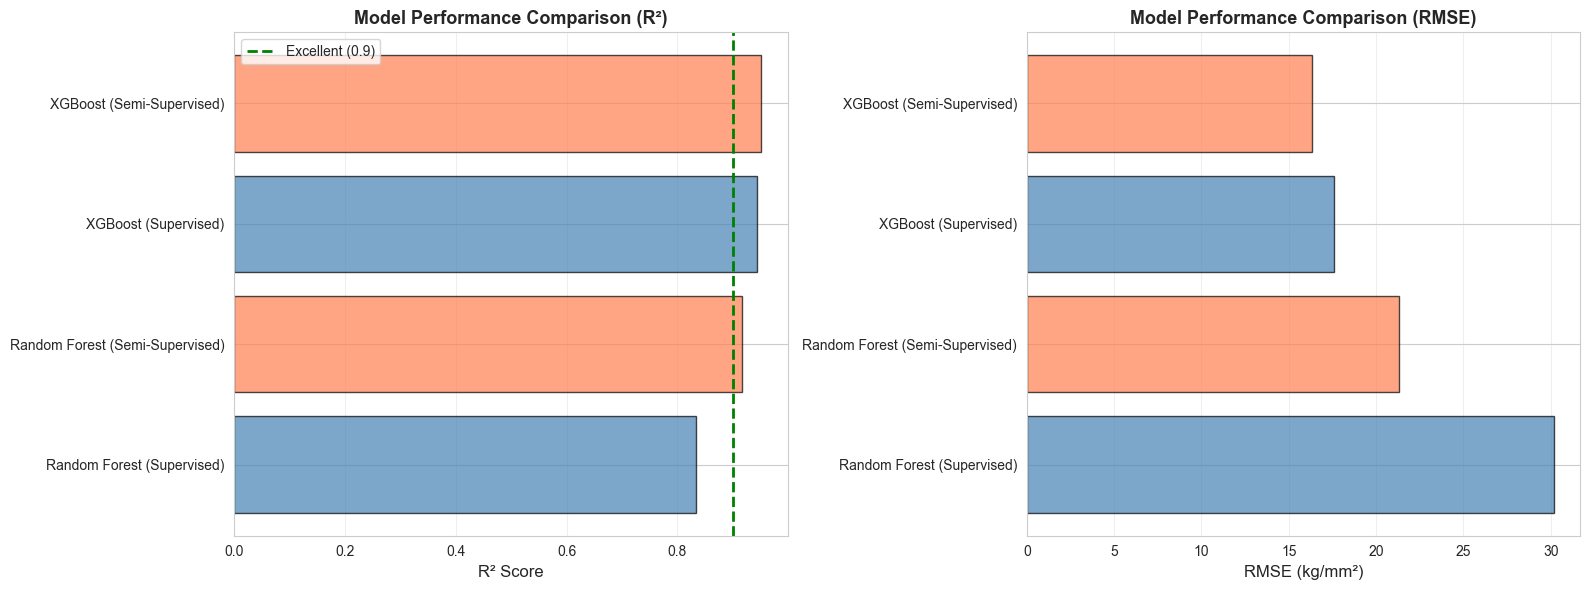

In [20]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² comparison
models = results_comparison['Model']
r2_values = results_comparison['R²']
colors = ['steelblue', 'coral', 'steelblue', 'coral']

axes[0].barh(models, r2_values, color=colors, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('R² Score', fontsize=12)
axes[0].set_title('Model Performance Comparison (R²)', fontsize=13, fontweight='bold')
axes[0].axvline(x=0.9, color='green', linestyle='--', linewidth=2, label='Excellent (0.9)')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# RMSE comparison
rmse_values = results_comparison['RMSE (kg/mm²)']

axes[1].barh(models, rmse_values, color=colors, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('RMSE (kg/mm²)', fontsize=12)
axes[1].set_title('Model Performance Comparison (RMSE)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('figures/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Select Best Model and Predict All Hardness

Use the best-performing model to predict hardness for all unlabeled samples.

In [21]:
# Identify best model
best_model_name = results_comparison.loc[best_model_idx, 'Model']

if 'XGBoost' in best_model_name and 'Semi-Supervised' in best_model_name:
    best_model = best_xgb_ssl
elif 'XGBoost' in best_model_name:
    best_model = best_xgb_supervised
elif 'Semi-Supervised' in best_model_name:
    best_model = best_rf_ssl
else:
    best_model = best_rf_supervised

print(f"\nBest Model: {best_model_name}")
print(f"  R²: {results_comparison.loc[best_model_idx, 'R²']:.4f}")
print(f"  RMSE: {results_comparison.loc[best_model_idx, 'RMSE (kg/mm²)']:.4f} kg/mm²")

# Save best model
joblib.dump(best_model, 'models/best_hardness_model.pkl')
print(f"\n✓ Best model saved to models/best_hardness_model.pkl")


Best Model: XGBoost (Semi-Supervised)
  R²: 0.9514
  RMSE: 16.3001 kg/mm²

✓ Best model saved to models/best_hardness_model.pkl


In [22]:
# Predict hardness for all samples (including unlabeled)
hardness_predictions_all = best_model.predict(X_clean)

# Create final dataset with predictions
hardness_final = df[[target_column]].copy()
hardness_final['Hardness_Predicted'] = hardness_predictions_all
hardness_final['Is_Original'] = hardness_final[target_column].notna()

# For unlabeled samples, replace NaN with predictions
hardness_final['Hardness_Final'] = hardness_final[target_column].fillna(hardness_final['Hardness_Predicted'])

print(f"\nPrediction Summary:")
print(f"  Original labeled: {hardness_final['Is_Original'].sum()}")
print(f"  Newly predicted: {(~hardness_final['Is_Original']).sum()}")
print(f"  Total complete: {len(hardness_final)}")

# Save predictions
hardness_final.to_csv('data/hardness_predictions_complete.csv', index=False)
print(f"\n✓ Complete hardness data saved to data/hardness_predictions_complete.csv")


Prediction Summary:
  Original labeled: 138
  Newly predicted: 1514
  Total complete: 1652

✓ Complete hardness data saved to data/hardness_predictions_complete.csv


## Analyze Predicted Hardness Distribution

Compare distributions of original labeled data vs predicted data to ensure predictions are reasonable.

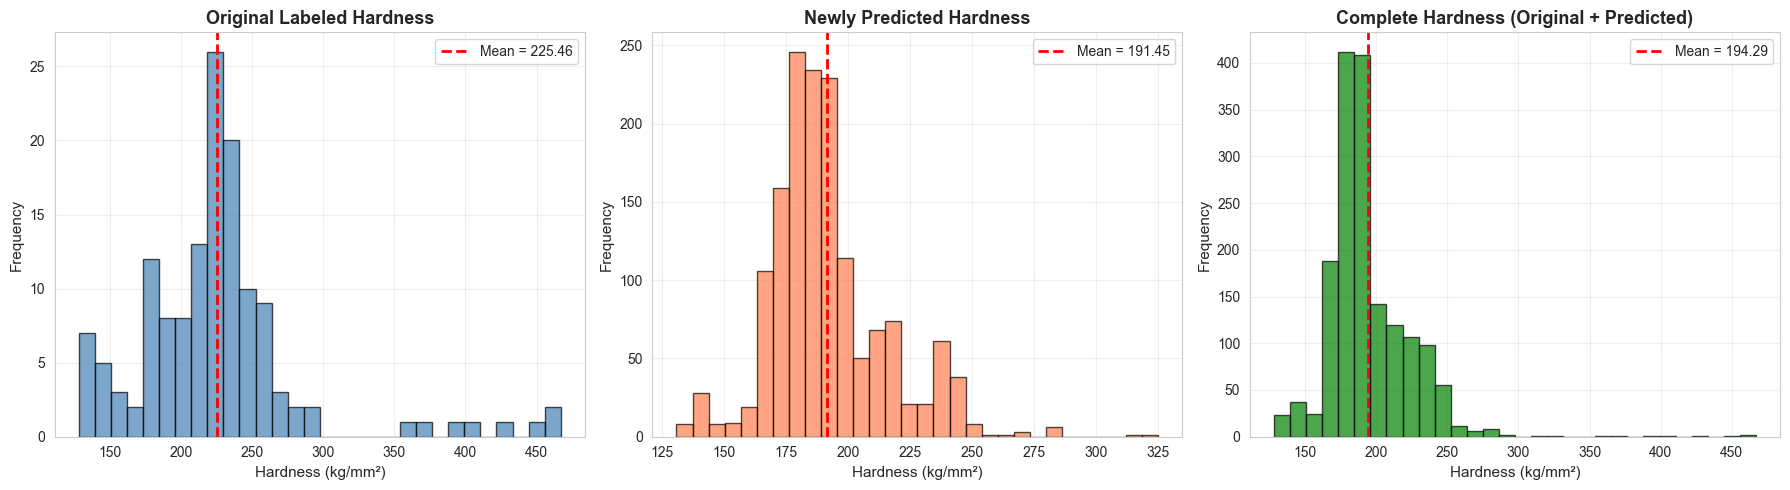


Distribution Statistics:

Original Labeled:
count    138.000000
mean     225.463039
std       60.384922
min      128.122060
25%      193.000000
50%      224.000000
75%      241.000000
max      467.000000
Name: Hardness_kg_mm2, dtype: float64

Newly Predicted:
count    1514.000000
mean      191.445923
std        23.675161
min       130.633987
25%       176.759552
50%       187.317207
75%       199.741501
max       325.017303
Name: Hardness_Predicted, dtype: float64

Complete Dataset:
count    1652.000000
mean      194.287543
std        30.081194
min       128.122060
25%       176.954468
50%       188.318069
75%       207.595734
max       467.000000
Name: Hardness_Final, dtype: float64


In [23]:
# Extract distributions
hardness_original = hardness_final[hardness_final['Is_Original']][target_column]
hardness_predicted_new = hardness_final[~hardness_final['Is_Original']]['Hardness_Predicted']
hardness_all_complete = hardness_final['Hardness_Final']

# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original data
axes[0].hist(hardness_original, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(hardness_original.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {hardness_original.mean():.2f}')
axes[0].set_title('Original Labeled Hardness', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hardness (kg/mm²)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Predicted data
axes[1].hist(hardness_predicted_new, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(hardness_predicted_new.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {hardness_predicted_new.mean():.2f}')
axes[1].set_title('Newly Predicted Hardness', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hardness (kg/mm²)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# All complete data
axes[2].hist(hardness_all_complete, bins=30, color='green', edgecolor='black', alpha=0.7)
axes[2].axvline(hardness_all_complete.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {hardness_all_complete.mean():.2f}')
axes[2].set_title('Complete Hardness (Original + Predicted)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Hardness (kg/mm²)', fontsize=11)
axes[2].set_ylabel('Frequency', fontsize=11)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/hardness_distribution_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nDistribution Statistics:")
print(f"\nOriginal Labeled:")
print(hardness_original.describe())
print(f"\nNewly Predicted:")
print(hardness_predicted_new.describe())
print(f"\nComplete Dataset:")
print(hardness_all_complete.describe())